/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


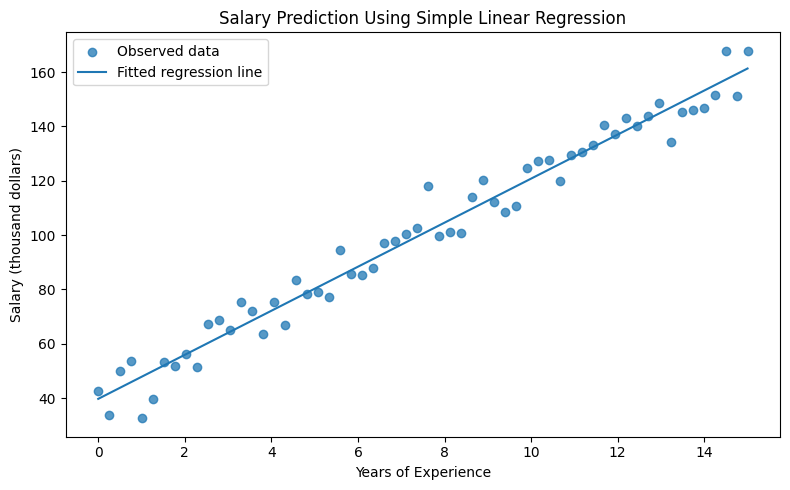

Intercept: 39.703705534457946
Slope: 8.109143758238245


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(42)

# Simulated salary data
experience = np.linspace(0, 15, 60)
salary = 40 + 8 * experience + rng.normal(0, 8, size=len(experience))

df = pd.DataFrame({
    "experience": experience,
    "salary": salary
})

X = df[["experience"]]
y = df["salary"]

model = LinearRegression()
model.fit(X, y)

x_grid = np.linspace(0, 15, 200).reshape(-1, 1)
y_pred = model.predict(x_grid)

plt.figure(figsize=(8, 5))
plt.scatter(df["experience"], df["salary"], alpha=0.75, label="Observed data")
plt.plot(x_grid, y_pred, label="Fitted regression line")
plt.title("Salary Prediction Using Simple Linear Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (thousand dollars)")
plt.legend()
plt.tight_layout()
plt.show()

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

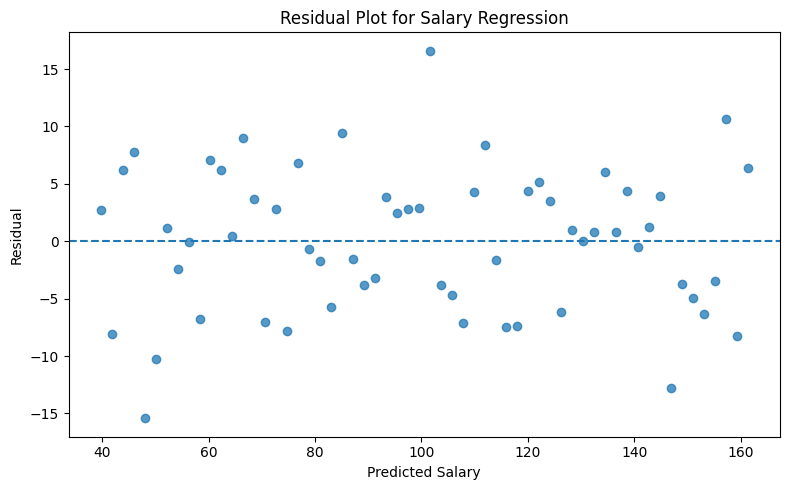

In [2]:
# Continuing from the salary example

df["predicted_salary"] = model.predict(X)
df["residual"] = df["salary"] - df["predicted_salary"]

plt.figure(figsize=(8, 5))
plt.scatter(df["predicted_salary"], df["residual"], alpha=0.75)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot for Salary Regression")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

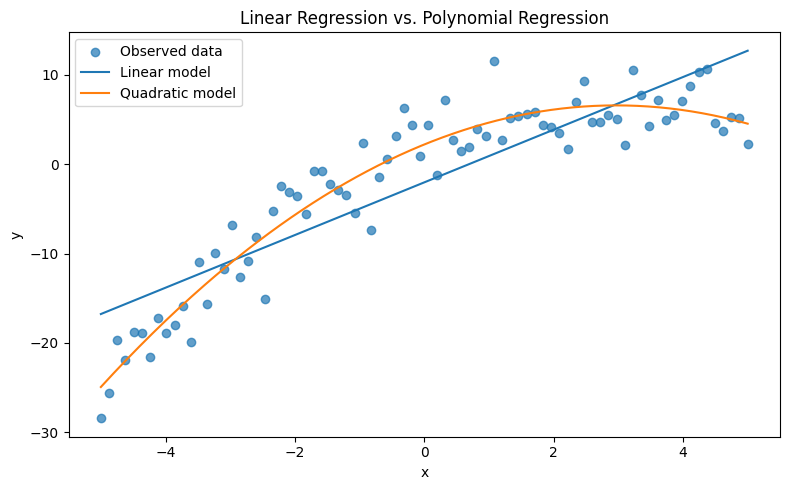

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(123)

X = np.linspace(-5, 5, 80).reshape(-1, 1)
y = 2 + 3 * X.ravel() - 0.5 * X.ravel()**2 + rng.normal(0, 3, size=X.shape[0])

x_grid = np.linspace(-5, 5, 300).reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X, y)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])
poly_model.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, label="Observed data")
plt.plot(x_grid, linear_model.predict(x_grid), label="Linear model")
plt.plot(x_grid, poly_model.predict(x_grid), label="Quadratic model")
plt.title("Linear Regression vs. Polynomial Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

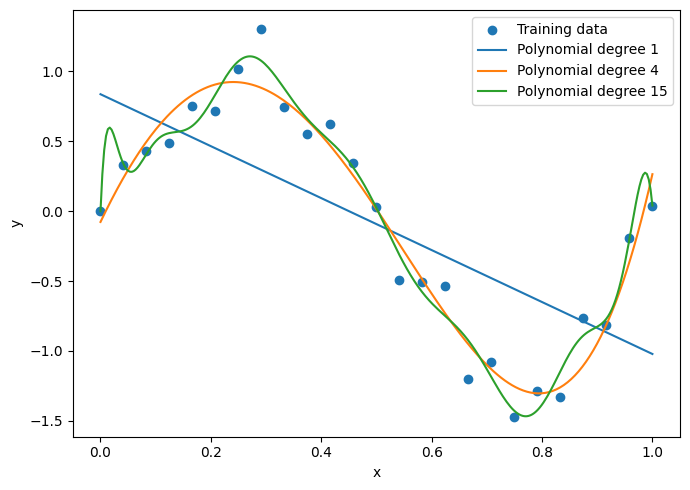

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(7)

X = np.linspace(0, 1, 25).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + rng.normal(0, 0.25, size=X.shape[0])

x_grid = np.linspace(0, 1, 300).reshape(-1, 1)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, label="Training data")
for degree in [1, 4, 15]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])
    model.fit(X, y)
    y_grid = model.predict(x_grid)
    plt.plot(x_grid, y_grid, label=f"Polynomial degree {degree}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

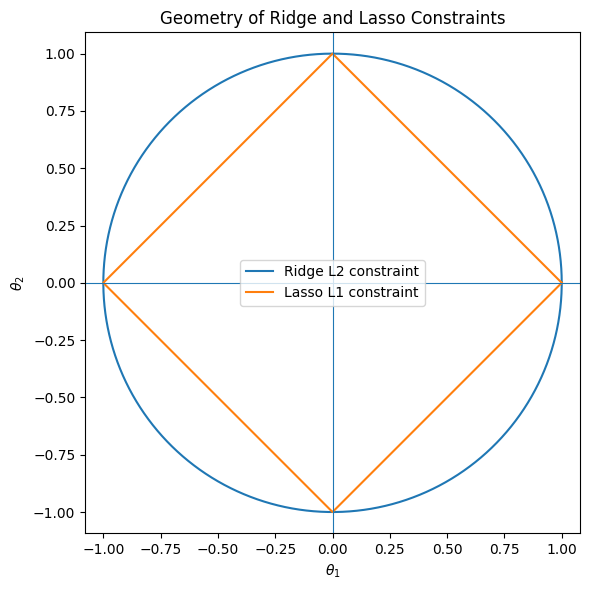

In [7]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 400)

# L2 ball boundary
x_l2 = np.cos(theta)
y_l2 = np.sin(theta)

# L1 ball boundary: |x| + |y| = 1
x_l1 = np.array([1, 0, -1, 0, 1])
y_l1 = np.array([0, 1, 0, -1, 0])

plt.figure(figsize=(6, 6))
plt.plot(x_l2, y_l2, label="Ridge L2 constraint")
plt.plot(x_l1, y_l1, label="Lasso L1 constraint")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Geometry of Ridge and Lasso Constraints")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

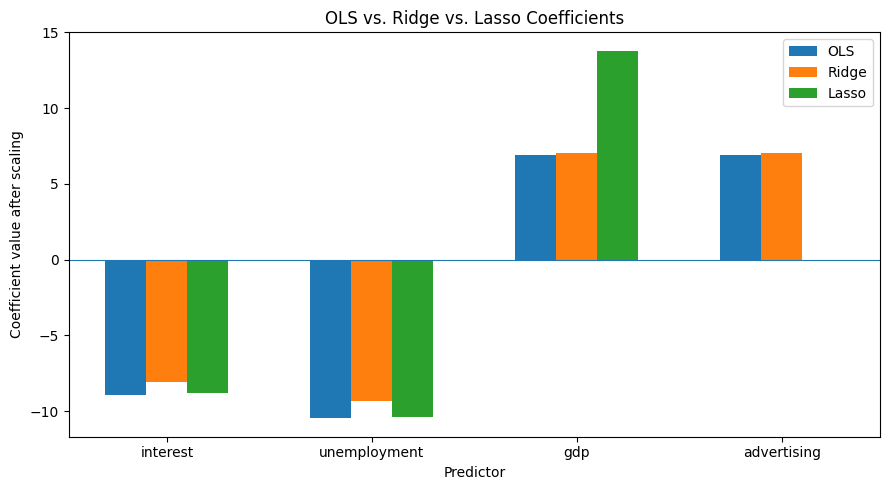

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)
n = 120

interest = rng.normal(4, 1, n)
unemployment = rng.normal(6, 1.5, n)
gdp = 3 - 0.4 * unemployment + rng.normal(0, 0.5, n)
advertising = 0.9 * gdp 

sales = (
    200
    - 8 * interest
    - 5 * unemployment
    + 20 * gdp
    + 0.5 * advertising
    + rng.normal(0, 15, n)
)

X = pd.DataFrame({
    "interest": interest,
    "unemployment": unemployment,
    "gdp": gdp,
    "advertising": advertising
})

y = sales

ols = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])
ols.fit(X, y)
ridge.fit(X, y)
lasso.fit(X, y)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "OLS": ols.named_steps["model"].coef_,
    "Ridge": ridge.named_steps["model"].coef_,
    "Lasso": lasso.named_steps["model"].coef_
})

x_pos = np.arange(len(coef_df))

plt.figure(figsize=(9, 5))
plt.bar(x_pos - 0.2, coef_df["OLS"], width=0.2, label="OLS")
plt.bar(x_pos , coef_df["Ridge"], width=0.2, label="Ridge")
plt.bar(x_pos + 0.2, coef_df["Lasso"],  width=0.2, label="Lasso")
plt.xticks(x_pos, coef_df["feature"])
plt.axhline(0, linewidth=0.8)
plt.title("OLS vs. Ridge vs. Lasso Coefficients")
plt.xlabel("Predictor")
plt.ylabel("Coefficient value after scaling")
plt.legend()
plt.tight_layout()
plt.show()

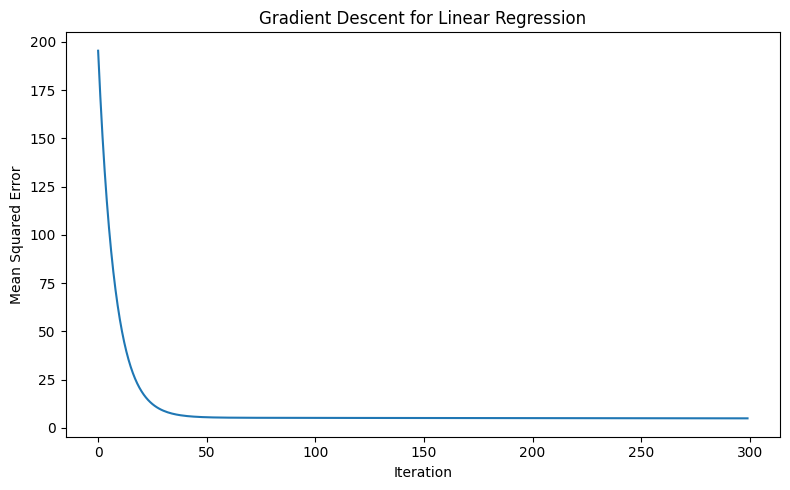

Estimated parameters: [0.70824809 2.36049641]


In [33]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 100
X_raw = rng.uniform(0, 10, n)
y = 3 + 2 * X_raw + rng.normal(0, 2, n)

# Add intercept column
Phi = np.column_stack([np.ones(n), X_raw])

theta = np.zeros(2)
alpha = 0.001
n_iter = 300

loss_history = []

for _ in range(n_iter):
    y_pred = Phi @ theta
    residual = y - y_pred
    loss = np.mean(residual**2)
    loss_history.append(loss)

    grad = -(2 / n) * Phi.T @ residual
    theta = theta - alpha * grad

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Gradient Descent for Linear Regression")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.tight_layout()
plt.show()

print("Estimated parameters:", theta)

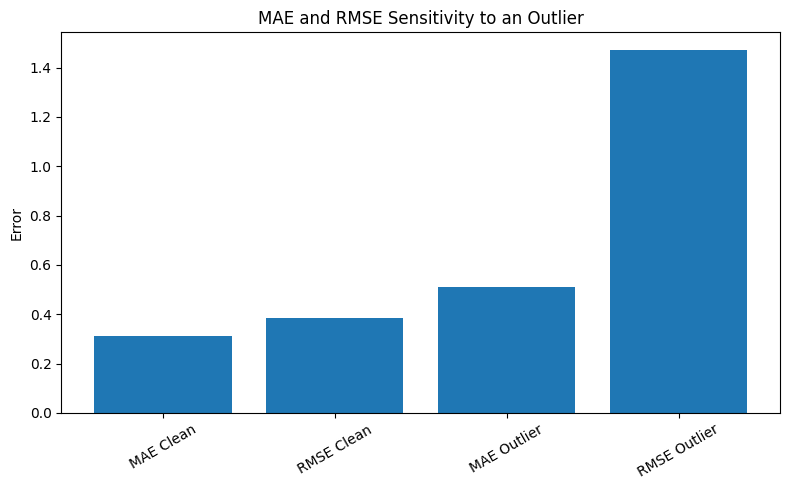

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

rng = np.random.default_rng(42)

y_true = np.linspace(0, 10, 50)
y_pred_clean = y_true + rng.normal(0, 0.5, size=50)

y_pred_outlier = y_pred_clean.copy()
y_pred_outlier[-1] += 10

mae_clean = mean_absolute_error(y_true, y_pred_clean)
rmse_clean = mean_squared_error(y_true, y_pred_clean) ** 0.5

mae_outlier = mean_absolute_error(y_true, y_pred_outlier)
rmse_outlier = mean_squared_error(y_true, y_pred_outlier) ** 0.5

metrics = ["MAE Clean", "RMSE Clean", "MAE Outlier", "RMSE Outlier"]
values = [mae_clean, rmse_clean, mae_outlier, rmse_outlier]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)
plt.title("MAE and RMSE Sensitivity to an Outlier")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

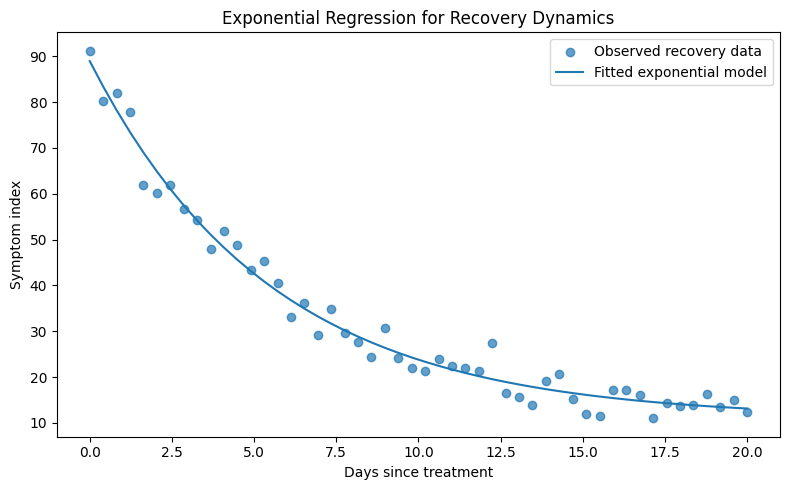

Estimated A, k, C: [77.88582361  0.18102926 11.0525079 ]


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(42)

def exp_decay(t, A, k, C):
    return A * np.exp(-k * t) + C

t = np.linspace(0, 20, 50)
true_y = exp_decay(t, A=80, k=0.18, C=10)
observed_y = true_y + rng.normal(0, 4, size=len(t))

params, _ = curve_fit(exp_decay, t, observed_y, p0=[70, 0.1, 5])
fitted_y = exp_decay(t, *params)

plt.figure(figsize=(8, 5))
plt.scatter(t, observed_y, alpha=0.7, label="Observed recovery data")
plt.plot(t, fitted_y, label="Fitted exponential model")
plt.title("Exponential Regression for Recovery Dynamics")
plt.xlabel("Days since treatment")
plt.ylabel("Symptom index")
plt.legend()
plt.tight_layout()
plt.show()

print("Estimated A, k, C:", params)

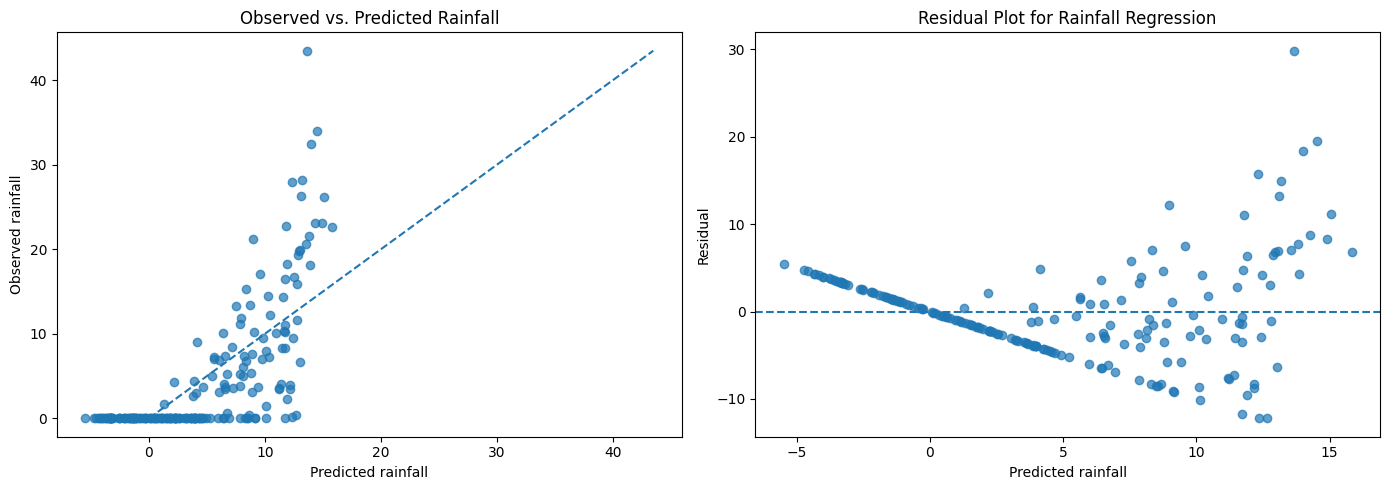

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(42)
n = 200

temperature = rng.normal(22, 5, n)
pressure = rng.normal(1010, 8, n)
wind = rng.normal(12, 3, n)
humidity = rng.uniform(40, 100, n)

rainfall = (
    -20
    + 0.3 * temperature
    - 0.05 * pressure
    + 0.4 * wind
    + 0.8 * humidity
    + rng.normal(0, 8, n)
)

rainfall = np.maximum(rainfall, 0)

X = pd.DataFrame({
    "temperature": temperature,
    "pressure": pressure,
    "wind": wind,
    "humidity": humidity
})

y = rainfall

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

# put these two plots together in a single figure
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred, y, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.title("Observed vs. Predicted Rainfall") 
plt.xlabel("Predicted rainfall")
plt.ylabel("Observed rainfall")
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot for Rainfall Regression")
plt.xlabel("Predicted rainfall")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()